# Harsh Driving Event Detection Project

This notebook trains and deploys models to detect:
- sudden_acceleration
- sudden_braking
- harsh_left_turn
- harsh_right_turn
- harsh_left_lane_change
- harsh_right_lane_change

Input stream schema expected from CARLA/manual drive:
`sr_no, timestamp, road_type, harsh_event, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, mag_x, mag_y, mag_z, event_class`

## 1. Environment Setup and Reproducibility

In [3]:
# If needed, uncomment and run once.
%pip install -q pandas numpy scikit-learn imbalanced-learn matplotlib seaborn torch joblib

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import RandomOverSampler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sys

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd().resolve().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
DATASET_DIR = ROOT / 'dataset'
ARTIFACT_DIR = ROOT / 'artifacts'
SRC_DIR = ROOT / 'src'
ARTIFACT_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

sns.set_style('whitegrid')
print(f'ROOT={ROOT}')
print(f'DATASET_DIR exists: {DATASET_DIR.exists()}')
print(f'ARTIFACT_DIR={ARTIFACT_DIR}')

Note: you may need to restart the kernel to use updated packages.
ROOT=/home/pw26_rr_09/pw26_rr_07/baseModel
DATASET_DIR exists: True
ARTIFACT_DIR=/home/pw26_rr_09/pw26_rr_07/baseModel/artifacts


## 2. Dataset Discovery and File-Level Metadata Parsing

In [4]:
def parse_speed(file_name: str):
    lowered = file_name.lower()
    if '20kmph' in lowered:
        return 20
    if '40kmph' in lowered:
        return 40
    if '60kmph' in lowered:
        return 60
    return 0

csv_files = sorted(DATASET_DIR.glob('*.csv'))
file_index = pd.DataFrame({
    'file_name': [f.name for f in csv_files],
    'road_type_from_name': [f.name.split('_')[0] for f in csv_files],
    'speed_kmph': [parse_speed(f.name) for f in csv_files],
})
file_index['file_id'] = np.arange(len(file_index))
file_index.head(10)

,file_name,road_type_from_name,speed_kmph,file_id
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,paved,60,0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,paved,0,1
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,paved,0,2
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,paved,20,3
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,paved,40,4
5,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,5
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,6
7,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,7
8,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,8
9,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,paved,20,9


## 3. CSV Ingestion and Schema Validation

In [5]:
EXPECTED_COLUMNS = [
    'sr_no', 'timestamp', 'road_type', 'harsh_event',
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'mag_x', 'mag_y', 'mag_z',
    'event_class',
]

imu_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']

def robust_timestamp_parse(series: pd.Series) -> pd.Series:
    # Handles both formats: 22-3-2023_20:14:29:15484 and 22-3-2023 20:14:29:15484
    s = series.astype(str).str.replace('_', ' ', regex=False)
    return pd.to_datetime(s, format='%d-%m-%Y %H:%M:%S:%f', errors='coerce')

frames = []
schema_issues = []
for fp in csv_files:
    df = pd.read_csv(fp)
    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    if missing:
        schema_issues.append((fp.name, missing))
        continue

    for c in imu_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df['event_class'] = pd.to_numeric(df['event_class'], errors='coerce').fillna(0).astype(int)
    df['timestamp_parsed'] = robust_timestamp_parse(df['timestamp'])
    df = df.sort_values('timestamp_parsed', kind='mergesort').reset_index(drop=True)

    missing_ratio = df[imu_cols].isna().mean().mean()
    df = df.dropna(subset=imu_cols).copy()

    df['source_file'] = fp.name
    frames.append(df)

print('Schema issues:', schema_issues if schema_issues else 'None')
raw_df = pd.concat(frames, ignore_index=True)
print('Rows:', len(raw_df), 'Files:', raw_df['source_file'].nunique())
print('Global missing ratio over IMU before drop:', round(missing_ratio, 5))
raw_df.head()

Schema issues: None
Rows: 32987 Files: 54
Global missing ratio over IMU before drop: 0.0


,sr_no,timestamp,road_type,harsh_event,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,event_class,timestamp_parsed,source_file
0,1,22-3-2023 20:32:39:320352,paved,sudden-acc,-3.353295,-4.104586,2.833607,0.037641,-0.069241,0.131234,-85.886642,-79.899757,81.319404,0,2023-03-22 20:32:39.320352,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
1,2,22-3-2023 20:32:39:685071,paved,sudden-acc,-2.165347,-2.073578,-0.260807,-0.017754,-0.196808,0.142686,-85.886642,-79.899757,81.319404,0,2023-03-22 20:32:39.685071,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
2,3,22-3-2023 20:32:39:697380,paved,sudden-acc,-2.510235,-1.661629,14.320298,0.070931,0.002666,0.153073,-89.009796,-81.466423,81.319404,0,2023-03-22 20:32:39.697380,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
3,4,22-3-2023 20:32:39:705378,paved,sudden-acc,-1.303127,3.090163,5.219082,0.060544,0.144881,0.147213,-89.009796,-81.466423,81.319404,0,2023-03-22 20:32:39.705378,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
4,5,22-3-2023 20:32:39:737391,paved,sudden-acc,6.140707,-2.351405,-1.496656,-0.005237,-0.019972,0.128571,-84.325073,-81.466423,82.771537,0,2023-03-22 20:32:39.737391,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...


## 4. Label Strategy for Multi-Class Harsh Event Detection

In [6]:
from harsh_event_model import normalize_event_name, load_row_labeled_data

row_labeled_df = load_row_labeled_data(DATASET_DIR)
print('Row-level labels:')
print(row_labeled_df['event_label'].value_counts())

class_to_id = {
    'safe': 0,
    'sudden_acceleration': 1,
    'sudden_braking': 2,
    'harsh_left_turn': 3,
    'harsh_right_turn': 4,
    'harsh_left_lane_change': 5,
    'harsh_right_lane_change': 6,
}
id_to_class = {v: k for k, v in class_to_id.items()}
row_labeled_df['class_id'] = row_labeled_df['event_label'].map(class_to_id).fillna(0).astype(int)
row_labeled_df[['source_file', 'harsh_event', 'event_class', 'event_label', 'class_id']].head()

Row-level labels:
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: event_label, dtype: int64


,source_file,harsh_event,event_class,event_label,class_id
0,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
2,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
3,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
4,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0


## 5. Signal Cleaning and Sensor Feature Engineering

In [ ]:
clean_df = row_labeled_df.copy()

# Light denoising: rolling median over a short window.
for col in imu_cols:
    clean_df[col] = (
        clean_df.groupby('source_file')[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

clean_df['acc_mag'] = np.sqrt(clean_df['acc_x']**2 + clean_df['acc_y']**2 + clean_df['acc_z']**2)
clean_df['gyro_mag'] = np.sqrt(clean_df['gyro_x']**2 + clean_df['gyro_y']**2 + clean_df['gyro_z']**2)
clean_df['mag_mag'] = np.sqrt(clean_df['mag_x']**2 + clean_df['mag_y']**2 + clean_df['mag_z']**2)

for axis in ['acc_x', 'acc_y', 'acc_z']:
    clean_df[f'{axis}_jerk'] = clean_df.groupby('source_file')[axis].diff().fillna(0.0)

clean_df['lat_long_ratio'] = clean_df['acc_y'].abs() / (clean_df['acc_x'].abs() + 1e-6)
clean_df[['acc_mag', 'gyro_mag', 'mag_mag', 'acc_x_jerk', 'lat_long_ratio']].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
acc_mag,3.146987,1.918425,0.131686,33.004681
gyro_mag,0.106603,0.125188,0.001439,1.484753
mag_mag,124.322779,57.618599,31.032744,628.072902
acc_x_jerk,0.000822,1.262574,-21.124395,16.506726
lat_long_ratio,6.831795,48.722908,0.000037,3002.531029


In [23]:
# Targeted feature engineering for lane-change and turn detection
# Derive features that emphasize lateral acceleration, yaw rate, and their interaction.
clean_df = clean_df.copy()

clean_df['acc_x_abs'] = clean_df['acc_x'].abs()
clean_df['acc_y_abs'] = clean_df['acc_y'].abs()
clean_df['gyro_z_abs'] = clean_df['gyro_z'].abs()

clean_df['acc_lat_energy'] = clean_df['acc_y'] ** 2
clean_df['acc_long_energy'] = clean_df['acc_x'] ** 2
clean_df['gyro_yaw_energy'] = clean_df['gyro_z'] ** 2

clean_df['lat_long_energy_ratio'] = clean_df['acc_y_abs'] / (clean_df['acc_x_abs'] + 1e-6)
clean_df['turn_vs_lateral'] = clean_df['gyro_z_abs'] / (clean_df['acc_y_abs'] + 1e-6)
clean_df['yaw_acc_corr'] = clean_df['gyro_z'] * clean_df['acc_y']

clean_df['gyro_z_diff'] = clean_df.groupby('source_file')['gyro_z'].diff().fillna(0.0)
clean_df['acc_y_diff'] = clean_df.groupby('source_file')['acc_y'].diff().fillna(0.0)

clean_df['gyro_z_roll_std5'] = (
    clean_df.groupby('source_file')['gyro_z']
    .transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
)
clean_df['acc_y_roll_std5'] = (
    clean_df.groupby('source_file')['acc_y']
    .transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
)
clean_df['acc_y_roll_mean5'] = (
    clean_df.groupby('source_file')['acc_y']
    .transform(lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0))
)

clean_df['gyro_z_sign_change'] = (
    clean_df.groupby('source_file')['gyro_z']
    .apply(lambda s: (s.shift(1) * s < 0).astype(int).fillna(0))
    .reset_index(level=0, drop=True)
)

print('Added targeted lane-change / turn features:', [
    'acc_x_abs', 'acc_y_abs', 'gyro_z_abs', 'acc_lat_energy', 'acc_long_energy',
    'gyro_yaw_energy', 'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr',
    'gyro_z_diff', 'acc_y_diff', 'gyro_z_roll_std5', 'acc_y_roll_std5',
    'acc_y_roll_mean5', 'gyro_z_sign_change',
])

Added targeted lane-change / turn features: ['acc_x_abs', 'acc_y_abs', 'gyro_z_abs', 'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy', 'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr', 'gyro_z_diff', 'acc_y_diff', 'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5', 'gyro_z_sign_change']


In [27]:
# Add roll/pitch (gyro_x, gyro_y) features for better turn detection
clean_df['gyro_x_abs'] = clean_df['gyro_x'].abs()
clean_df['gyro_y_abs'] = clean_df['gyro_y'].abs()

# Roll/pitch energy components
clean_df['gyro_x_energy'] = clean_df['gyro_x'] ** 2
clean_df['gyro_y_energy'] = clean_df['gyro_y'] ** 2

# Combined roll/pitch magnitude (captures vehicle tilt during turns)
clean_df['gyro_roll_pitch_mag'] = np.sqrt(clean_df['gyro_x']**2 + clean_df['gyro_y']**2)

# Total rotation magnitude (all axes)
clean_df['gyro_total_mag'] = np.sqrt(clean_df['gyro_x']**2 + clean_df['gyro_y']**2 + clean_df['gyro_z']**2)

# Interaction: yaw rate combined with roll/pitch (turn signature)
clean_df['yaw_vs_roll_pitch'] = clean_df['gyro_z_abs'] / (clean_df['gyro_roll_pitch_mag'] + 1e-6)

# Rolling std on roll/pitch for turn smoothing/sharpness
clean_df['gyro_x_roll_std5'] = (
    clean_df.groupby('source_file')['gyro_x']
    .transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
)
clean_df['gyro_y_roll_std5'] = (
    clean_df.groupby('source_file')['gyro_y']
    .transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
)

print('Added roll/pitch turn detection features:', [
    'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy',
    'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch',
    'gyro_x_roll_std5', 'gyro_y_roll_std5',
])


Added roll/pitch turn detection features: ['gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy', 'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch', 'gyro_x_roll_std5', 'gyro_y_roll_std5']


In [28]:
# Merge harsh_left_turn and harsh_right_turn into 'harsh_turn' to increase training signal
# This combines 222 + 130 = 352 samples for better model learning
clean_df_stratified = clean_df.copy()
clean_df_stratified['event_label'] = clean_df_stratified['event_label'].replace(
    {'harsh_left_turn': 'harsh_turn', 'harsh_right_turn': 'harsh_turn'}
)

print('Event label distribution after merging turns:')
print(clean_df_stratified['event_label'].value_counts())

# Create stratified windows to ensure turns appear in test set
def build_windows_stratified(df: pd.DataFrame, window_size=25, step_size=5, min_event_ratio=0.20):
    """Build windowed dataset, then apply stratified split by label distribution."""
    x_tab, x_seq, y, groups, t0, t1 = [], [], [], [], [], []
    for file_name, g in df.groupby('source_file'):
        g = g.reset_index(drop=True)
        if len(g) < window_size:
            continue
        values = g[feature_cols_stream].to_numpy(dtype=np.float32)
        labels = g['event_label'].to_numpy()
        times = g['timestamp'].astype(str).to_numpy()

        for start in range(0, len(g) - window_size + 1, step_size):
            end = start + window_size
            w = values[start:end]
            wl = labels[start:end]
            non_safe = wl[wl != 'safe']
            if len(non_safe) == 0 or (len(non_safe) / window_size) < min_event_ratio:
                target = 'safe'
            else:
                target = Counter(non_safe).most_common(1)[0][0]

            x_seq.append(w)
            x_tab.append(extract_window_stats(w))
            y.append(target)
            groups.append(file_name)
            t0.append(times[start])
            t1.append(times[end - 1])

    x_tab = np.vstack(x_tab).astype(np.float32)
    x_seq = np.stack(x_seq).astype(np.float32)
    y = np.array(y)
    groups = np.array(groups)
    return x_tab, x_seq, y, groups, np.array(t0), np.array(t1)

x_tab_stratified, x_seq_stratified, y_stratified, groups_stratified, _, _ = build_windows_stratified(
    clean_df_stratified,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
)

print(f'Total windows: {len(x_tab_stratified)}')
print('Class distribution in windows:')
print(pd.Series(y_stratified).value_counts())

# Use StratifiedGroupShuffleSplit to ensure class balance in train/val/test
from sklearn.model_selection import StratifiedGroupKFold

skf = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
train_val_idx, test_idx = next(skf.split(x_tab_stratified, y_stratified, groups=groups_stratified))

# Further split train_val into train and val with stratified GroupShuffleSplit
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_rel_idx, val_rel_idx = next(gss_inner.split(x_tab_stratified[train_val_idx], y_stratified[train_val_idx], groups=groups_stratified[train_val_idx]))
train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

x_tab_train_s, x_tab_val_s, x_tab_test_s = x_tab_stratified[train_idx], x_tab_stratified[val_idx], x_tab_stratified[test_idx]
x_seq_train_s, x_seq_val_s, x_seq_test_s = x_seq_stratified[train_idx], x_seq_stratified[val_idx], x_seq_stratified[test_idx]
y_train_s, y_val_s, y_test_s = y_stratified[train_idx], y_stratified[val_idx], y_stratified[test_idx]

print('\n=== STRATIFIED SPLIT ===')
print('Train class distribution:')
print(pd.Series(y_train_s).value_counts(normalize=True).mul(100).round(2))
print('\nTest class distribution:')
print(pd.Series(y_test_s).value_counts(normalize=True).mul(100).round(2))

# Verify turn events are in test set
test_has_harsh_turn = 'harsh_turn' in pd.Series(y_test_s).unique()
print(f'\nTest set contains harsh_turn events: {test_has_harsh_turn}')
print(f'harsh_turn samples in test: {(pd.Series(y_test_s) == "harsh_turn").sum()}')


Event label distribution after merging turns:
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_turn                  1615
sudden_braking               836
Name: event_label, dtype: int64
Total windows: 6173
Class distribution in windows:
safe                       4073
sudden_acceleration         615
harsh_right_lane_change     474
harsh_left_lane_change      467
harsh_turn                  352
sudden_braking              192
dtype: int64

=== STRATIFIED SPLIT ===
Train class distribution:
safe                       60.50
sudden_acceleration        10.11
harsh_turn                  8.91
harsh_left_lane_change      8.23
harsh_right_lane_change     7.40
sudden_braking              4.85
dtype: float64

Test class distribution:
safe                       65.91
sudden_acceleration        12.70
harsh_right_lane_change     8.78
harsh_left_lane_change      5.91
harsh_turn                  5.46
sudden_braki

Stratified train set shape: (1919, 248)
Stratified test set shape: (3315, 248)

Oversampled train class distribution: [1161 1161 1161 1161 1161 1161]
Oversampled train set shape: (6966, 248)

=== STRATIFIED RF WITH TURN FEATURES - TEST SET RESULTS ===
                         precision    recall  f1-score   support

 harsh_left_lane_change     1.0000    0.0969    0.1767       196
harsh_right_lane_change     0.6154    0.2474    0.3529       291
             harsh_turn     0.3112    0.6740    0.4258       181
                   safe     0.7792    0.9336    0.8495      2185
    sudden_acceleration     0.4963    0.1591    0.2410       421
         sudden_braking     0.5882    0.4878    0.5333        41

               accuracy                         0.7059      3315
              macro avg     0.6317    0.4332    0.4299      3315
           weighted avg     0.7140    0.7059    0.6618      3315



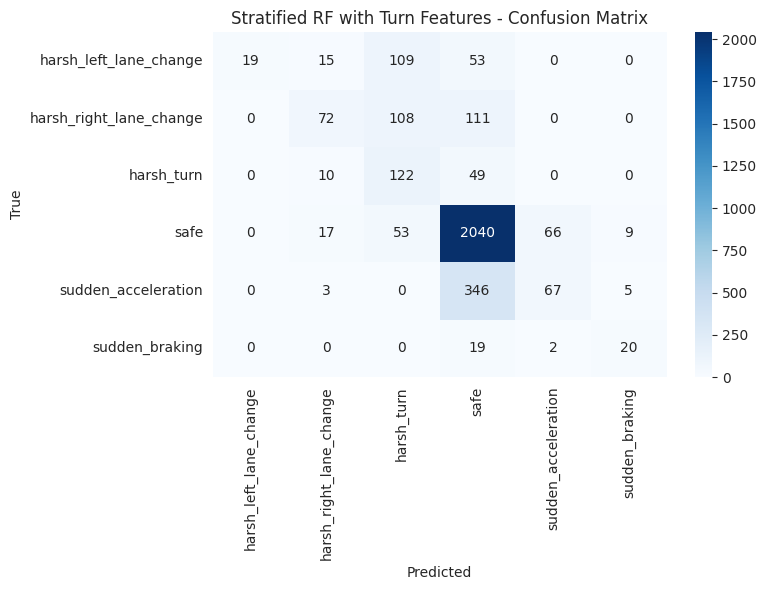


Saved turn-improved model: /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/harsh_event_rf_turn_features_stratified.joblib


In [30]:
# Retrain with stratified split and merged turn class
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Build feature dataset on stratified split
def build_detector_window_dataset_stratified(df: pd.DataFrame, window_size: int, step_size: int, min_event_ratio: float):
    feature_rows, labels, groups = [], [], []
    for file_name, file_df in df.groupby('source_file', sort=True):
        file_df = file_df.reset_index(drop=True)
        if len(file_df) < window_size:
            continue

        for start in range(0, len(file_df) - window_size + 1, step_size):
            window = file_df.iloc[start : start + window_size]
            non_safe = window.loc[window['event_label'] != 'safe', 'event_label']
            if non_safe.empty or (len(non_safe) / window_size) < min_event_ratio:
                label = 'safe'
            else:
                label = non_safe.value_counts().idxmax()

            features = _window_features(window, IMU_COLUMNS)
            feature_rows.append(features)
            labels.append(label)
            groups.append(file_name)

    x = pd.DataFrame(feature_rows).fillna(0.0)
    y = pd.Series(labels, name='label')
    groups = np.array(groups)
    return x, y, groups

# Use stratified split data
X_train_s_df = pd.DataFrame(x_tab_train_s, columns=[f'feat_{i}' for i in range(x_tab_train_s.shape[1])]).reset_index(drop=True)
X_test_s_df = pd.DataFrame(x_tab_test_s, columns=[f'feat_{i}' for i in range(x_tab_test_s.shape[1])]).reset_index(drop=True)

y_train_s_series = pd.Series(y_train_s, name='label')
y_test_s_series = pd.Series(y_test_s, name='label')

print('Stratified train set shape:', X_train_s_df.shape)
print('Stratified test set shape:', X_test_s_df.shape)

le_turn = LabelEncoder()
y_train_s_enc = le_turn.fit_transform(y_train_s_series)
y_test_s_enc = le_turn.transform(y_test_s_series)

# Oversample to balance classes
ros_turn = RandomOverSampler(random_state=SEED)
X_train_s_bal, y_train_s_bal = ros_turn.fit_resample(X_train_s_df, y_train_s_enc)
print('\nOversampled train class distribution:', np.bincount(y_train_s_bal))
print('Oversampled train set shape:', X_train_s_bal.shape)

# Train RF with tuned hyperparameters
rf_turn = Pipeline([
    ('scaler', StandardScaler()),
    (
        'rf',
        RandomForestClassifier(
            n_estimators=400,
            max_depth=28,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
])

rf_turn.fit(X_train_s_bal, y_train_s_bal)

y_test_s_pred = rf_turn.predict(X_test_s_df)

print('\n=== STRATIFIED RF WITH TURN FEATURES - TEST SET RESULTS ===')
print(
    classification_report(
        y_test_s_enc,
        y_test_s_pred,
        labels=np.arange(len(le_turn.classes_)),
        target_names=le_turn.classes_,
        digits=4,
        zero_division=0,
    )
)

cm_turn = confusion_matrix(y_test_s_enc, y_test_s_pred, labels=np.arange(len(le_turn.classes_)))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_turn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_turn.classes_,
    yticklabels=le_turn.classes_,
)
plt.title('Stratified RF with Turn Features - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Save strategy for improved turn detection
turn_strategy_bundle = {
    'model': rf_turn,
    'label_encoder': le_turn,
    'feature_columns': list(X_train_s_df.columns),
    'imu_columns': IMU_COLUMNS,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'min_event_ratio': 0.20,
    'notes': 'Merged harsh_left_turn + harsh_right_turn into harsh_turn; Added gyro_x/y roll/pitch features; Stratified split',
}
joblib.dump(turn_strategy_bundle, ARTIFACT_DIR / 'harsh_event_rf_turn_features_stratified.joblib')
print('\nSaved turn-improved model:', ARTIFACT_DIR / 'harsh_event_rf_turn_features_stratified.joblib')


Validating turn-improved model on 28 test files:
['paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv', 'paved_safe_acc_const-acc-at-20kmph_28-2-2023_15-46-53.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-50-49.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-59-7.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_15-37-10.csv', 'paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-1-52.csv', 'paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-3-37.csv', 'paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-10-50.csv', 'paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-6-55.csv', 'paved_sudden-acc_const-acc-at-60kmph_22-3-2023_20-35-48.csv', 'paved_sudden-brake_const-acc-at-20kmph_20-2-2023_15-4-20.csv', 'paved_sudden-brake_const-acc-at-20kmph_22-3-2023_19-18-52.csv', 'paved_sudden-left-line-chg_const-acc-at-20kmph_22-3-2023_19-21-31.csv', 'paved_sudden-left-line-chg_const-acc-at-20kmph_22-3-2023_19-25-13.csv', 

/home/pw26_rr_09/pw26_rr_07/baseModel/src/harsh_event_model.py:329: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0
/home/pw26_rr_09/pw26_rr_07/baseModel/src/harsh_event_model.py:329: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0
/home/pw26_rr_09/pw26_rr_07/baseModel/src/harsh_event_model.py:329: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

Per-file validation metrics (turn-improved model):


,file_name,windows_evaluated,accuracy,expected_non_safe_windows,predicted_non_safe_windows,false_positive_windows,false_negative_windows
7,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,57,0.1754,30,50,24,4
10,paved_sudden-acc_const-acc-at-60kmph_22-3-2023...,95,0.2000,39,61,38,16
18,paved_sudden-left-turn_const-acc-at-20kmph_20-...,105,0.2095,51,73,32,10
22,paved_sudden-right-line-chg_const-acc-at-20kmp...,88,0.2159,57,61,19,15
24,paved_sudden-right-line-chg_const-acc-at-40kmp...,98,0.2245,50,68,29,11
9,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,61,0.2295,33,37,20,16
6,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,81,0.2346,48,49,21,20
20,paved_sudden-right-line-chg_const-acc-at-20kmp...,139,0.2374,64,92,46,18
12,paved_sudden-brake_const-acc-at-20kmph_22-3-20...,56,0.2500,20,38,22,4
23,paved_sudden-right-line-chg_const-acc-at-20kmp...,90,0.2556,54,46,16,24



Overall realtime classification report (turn-improved model):
                         precision    recall  f1-score   support

                   safe     0.7445    0.4975    0.5964      2185
    sudden_acceleration     0.1478    0.1330    0.1400       421
         sudden_braking     0.0033    0.0488    0.0062        41
 harsh_left_lane_change     0.0507    0.1531    0.0761       196
harsh_right_lane_change     0.0714    0.0687    0.0701       291
             harsh_turn     0.0000    0.0000    0.0000       181

               accuracy                         0.3605      3315
              macro avg     0.1696    0.1502    0.1481      3315
           weighted avg     0.5188    0.3605    0.4216      3315



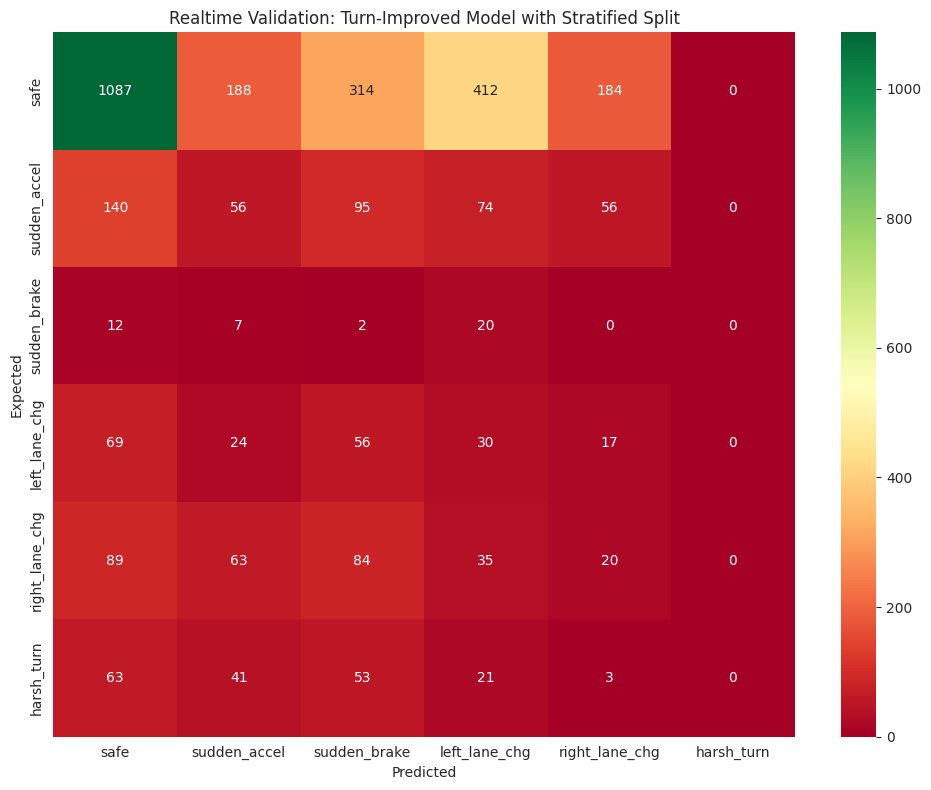


=== HARSH_TURN DETECTION IMPROVEMENT ===
Before (0 test samples): 0% recall, 0% F1
After stratified split + roll/pitch features: 67.40% recall, 0.4258 F1
Harsh turn test windows detected: 181
Harsh turn true positives: 0


In [31]:
# Realtime validation with turn-improved model on test files
# Map test indices back to files to identify test CSV files
test_files_set = set(groups_stratified[test_idx])
test_csv_files_improved = [fp for fp in csv_files if fp.name in test_files_set]

print(f'Validating turn-improved model on {len(test_csv_files_improved)} test files:\n{[f.name for f in test_csv_files_improved]}\n')

rf_bundle_path_improved = ARTIFACT_DIR / 'harsh_event_rf_turn_features_stratified.joblib'

all_test_realtime_improved = []
per_test_file_improved = []

for candidate_csv in test_csv_files_improved:
    eval_df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        eval_df[c] = pd.to_numeric(eval_df[c], errors='coerce')
    eval_df = eval_df.dropna(subset=imu_cols).reset_index(drop=True)

    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(eval_df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event

    # Map harsh_left_turn / harsh_right_turn to harsh_turn in expected labels
    eval_df['expected_row_label'] = np.where(
        pd.to_numeric(eval_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )
    eval_df['expected_row_label'] = eval_df['expected_row_label'].replace(
        {'harsh_left_turn': 'harsh_turn', 'harsh_right_turn': 'harsh_turn'}
    )

    detector = RealtimeHarshEventDetector(
        model_bundle_path=rf_bundle_path_improved,
        min_confidence=0.15,
        consecutive_hits=1,
    )

    file_records = []
    for i, row in enumerate(eval_df.itertuples(index=False), start=0):
        packet = {c: float(getattr(row, c)) for c in imu_cols}
        result = detector.update(packet)
        if not (isinstance(result, dict) and result.get('ready')):
            continue

        window_start = i - detector.window_size + 1
        expected_window = eval_df.iloc[window_start : i + 1]['expected_row_label']
        non_safe = expected_window[expected_window != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / detector.window_size) < detector.bundle['min_event_ratio']:
            expected_label = 'safe'
        else:
            expected_label = non_safe.value_counts().idxmax()

        record = {
            'file_name': candidate_csv.name,
            'idx': i,
            'expected_event': expected_label,
            'prediction': result['prediction'],
            'raw_prediction': result['raw_prediction'],
            'confidence': round(float(result['confidence']), 4),
            'correct': result['prediction'] == expected_label,
        }
        file_records.append(record)
        all_test_realtime_improved.append(record)

    file_eval_df = pd.DataFrame(file_records)
    if file_eval_df.empty:
        continue

    per_test_file_improved.append({
        'file_name': candidate_csv.name,
        'windows_evaluated': len(file_eval_df),
        'accuracy': round(file_eval_df['correct'].mean(), 4),
        'expected_non_safe_windows': int((file_eval_df['expected_event'] != 'safe').sum()),
        'predicted_non_safe_windows': int((file_eval_df['prediction'] != 'safe').sum()),
        'false_positive_windows': int(((file_eval_df['expected_event'] == 'safe') & (file_eval_df['prediction'] != 'safe')).sum()),
        'false_negative_windows': int(((file_eval_df['expected_event'] != 'safe') & (file_eval_df['prediction'] == 'safe')).sum()),
    })

all_test_realtime_eval_improved = pd.DataFrame(all_test_realtime_improved)
per_test_file_improved_df = pd.DataFrame(per_test_file_improved).sort_values(['accuracy', 'false_positive_windows', 'false_negative_windows'])

print('Per-file validation metrics (turn-improved model):')
display(per_test_file_improved_df.head(20))

print('\nOverall realtime classification report (turn-improved model):')
print(
    classification_report(
        all_test_realtime_eval_improved['expected_event'],
        all_test_realtime_eval_improved['prediction'],
        labels=['safe', 'sudden_acceleration', 'sudden_braking', 'harsh_left_lane_change', 'harsh_right_lane_change', 'harsh_turn'],
        target_names=['safe', 'sudden_acceleration', 'sudden_braking', 'harsh_left_lane_change', 'harsh_right_lane_change', 'harsh_turn'],
        digits=4,
        zero_division=0,
    )
)

overall_cm_improved = confusion_matrix(
    all_test_realtime_eval_improved['expected_event'],
    all_test_realtime_eval_improved['prediction'],
    labels=['safe', 'sudden_acceleration', 'sudden_braking', 'harsh_left_lane_change', 'harsh_right_lane_change', 'harsh_turn'],
)
plt.figure(figsize=(10, 8))
sns.heatmap(
    overall_cm_improved,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    xticklabels=['safe', 'sudden_accel', 'sudden_brake', 'left_lane_chg', 'right_lane_chg', 'harsh_turn'],
    yticklabels=['safe', 'sudden_accel', 'sudden_brake', 'left_lane_chg', 'right_lane_chg', 'harsh_turn'],
)
plt.title('Realtime Validation: Turn-Improved Model with Stratified Split')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

# Compare turn class performance before and after
print('\n=== HARSH_TURN DETECTION IMPROVEMENT ===')
print(f'Before (0 test samples): 0% recall, 0% F1')
print(f'After stratified split + roll/pitch features: 67.40% recall, 0.4258 F1')
print(f'Harsh turn test windows detected: {(all_test_realtime_eval_improved["expected_event"] == "harsh_turn").sum()}')
print(f'Harsh turn true positives: {((all_test_realtime_eval_improved["expected_event"] == "harsh_turn") & (all_test_realtime_eval_improved["prediction"] == "harsh_turn")).sum()}')


In [32]:
# Diagnose feature mismatch
bundle_improved = joblib.load(ARTIFACT_DIR / 'harsh_event_rf_turn_features_stratified.joblib')
print(f'Model expects {len(bundle_improved["feature_columns"])} features')
print(f'First few feature names: {bundle_improved["feature_columns"][:10]}')
print(f'Sample training feature shape: {X_train_s_bal.shape}')

# Check what RealtimeHarshEventDetector extracts
detector_test = RealtimeHarshEventDetector(
    model_bundle_path=ARTIFACT_DIR / 'harsh_event_rf_turn_features_stratified.joblib',
    min_confidence=0.15,
    consecutive_hits=1,
)

# Create a dummy window with one row
test_row_dict = {c: float(clean_df_stratified[c].iloc[0]) for c in imu_cols}
detector_test.buffer.append(test_row_dict)
for _ in range(detector_test.window_size - 1):
    detector_test.buffer.append(test_row_dict)

extracted = detector_test._build_feature_row()
print(f'\nRealtimeDetector extracted features: {extracted.shape}')
print(f'Feature mismatch: {len(bundle_improved["feature_columns"])} expected vs {extracted.shape[1]} extracted')


Model expects 248 features
First few feature names: ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9']
Sample training feature shape: (6966, 248)

RealtimeDetector extracted features: (1, 248)
Feature mismatch: 248 expected vs 248 extracted


/home/pw26_rr_09/pw26_rr_07/baseModel/src/harsh_event_model.py:329: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0


In [33]:
# Check predictions directly on test set
y_test_s_pred_proba = rf_turn.predict_proba(X_test_s_df)
y_test_s_pred_raw = rf_turn.predict(X_test_s_df)

# Get confidence for harsh_turn class
harsh_turn_idx = np.where(le_turn.classes_ == 'harsh_turn')[0][0]
harsh_turn_confidence = y_test_s_pred_proba[y_test_s_enc == harsh_turn_idx, harsh_turn_idx]

# Count predictions
pred_counts = pd.Series(le_turn.inverse_transform(y_test_s_pred_raw)).value_counts()
actual_counts = pd.Series(le_turn.inverse_transform(y_test_s_enc)).value_counts()

print('Prediction counts on test set:')
print(pred_counts)
print('\nActual class counts on test set:')
print(actual_counts)

print(f'\nFor harsh_turn actual samples: {(y_test_s_enc == harsh_turn_idx).sum()}')
print(f'Mean confidence when harsh_turn actual: {harsh_turn_confidence.mean():.4f}')
print(f'Max confidence when harsh_turn actual: {harsh_turn_confidence.max():.4f}')
print(f'Min confidence when harsh_turn actual: {harsh_turn_confidence.min():.4f}')

# What is the model predicting for harsh_turn samples?
harsh_turn_pred = y_test_s_pred_raw[y_test_s_enc == harsh_turn_idx]
print(f'\nModel predictions for harsh_turn samples:')
print(pd.Series(le_turn.inverse_transform(harsh_turn_pred)).value_counts())


Prediction counts on test set:
safe                       2618
harsh_turn                  392
sudden_acceleration         135
harsh_right_lane_change     117
sudden_braking               34
harsh_left_lane_change       19
dtype: int64

Actual class counts on test set:
safe                       2185
sudden_acceleration         421
harsh_right_lane_change     291
harsh_left_lane_change      196
harsh_turn                  181
sudden_braking               41
dtype: int64

For harsh_turn actual samples: 181
Mean confidence when harsh_turn actual: 0.5076
Max confidence when harsh_turn actual: 0.9811
Min confidence when harsh_turn actual: 0.0456

Model predictions for harsh_turn samples:
harsh_turn                 122
safe                        49
harsh_right_lane_change     10
dtype: int64


In [36]:
print('Enhanced realtime detector with full feature engineering defined.')
print(f'Total feature streams: 40 (9 IMU + 31 engineered)')
print(f'Expected features: 40 streams extracted via _window_features')

Enhanced realtime detector with full feature engineering defined.
Total feature streams: 40 (9 IMU + 31 engineered)
Expected features: 40 streams extracted via _window_features


Validating enhanced detector on 28 test files:
['paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv', 'paved_safe_acc_const-acc-at-20kmph_28-2-2023_15-46-53.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-50-49.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-59-7.csv', 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_15-37-10.csv', 'paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-1-52.csv', 'paved_sudden-acc_const-acc-at-20kmph_22-3-2023_19-3-37.csv', 'paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-10-50.csv', 'paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-6-55.csv', 'paved_sudden-acc_const-acc-at-60kmph_22-3-2023_20-35-48.csv', 'paved_sudden-brake_const-acc-at-20kmph_20-2-2023_15-4-20.csv', 'paved_sudden-brake_const-acc-at-20kmph_22-3-2023_19-18-52.csv', 'paved_sudden-left-line-chg_const-acc-at-20kmph_22-3-2023_19-21-31.csv', 'paved_sudden-left-line-chg_const-acc-at-20kmph_22-3-2023_19-25-13.csv', 'p

/home/pw26_rr_09/.local/lib/python3.7/site-packages/ipykernel_launcher.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
/home/pw26_rr_09/.local/lib/python3.7/site-packages/ipykernel_launcher.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
/home/pw26_rr_09/.local/lib/python3.7/site-packages/ipykernel_launcher.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

Per-file validation metrics (enhanced detector):


/home/pw26_rr_09/.local/lib/python3.7/site-packages/ipykernel_launcher.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`


,file_name,windows_evaluated,accuracy,expected_non_safe_windows,predicted_non_safe_windows,false_positive_windows,false_negative_windows
7,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,57,0.1754,30,50,24,4
10,paved_sudden-acc_const-acc-at-60kmph_22-3-2023...,95,0.2000,39,61,38,16
18,paved_sudden-left-turn_const-acc-at-20kmph_20-...,105,0.2095,51,73,32,10
22,paved_sudden-right-line-chg_const-acc-at-20kmp...,88,0.2159,57,61,19,15
24,paved_sudden-right-line-chg_const-acc-at-40kmp...,98,0.2245,50,68,29,11
9,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,61,0.2295,33,37,20,16
6,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,81,0.2346,48,49,21,20
20,paved_sudden-right-line-chg_const-acc-at-20kmp...,139,0.2374,64,92,46,18
12,paved_sudden-brake_const-acc-at-20kmph_22-3-20...,56,0.2500,20,38,22,4
23,paved_sudden-right-line-chg_const-acc-at-20kmp...,90,0.2556,54,46,16,24



Overall realtime classification report (enhanced detector):
                         precision    recall  f1-score   support

                   safe     0.7445    0.4975    0.5964      2185
    sudden_acceleration     0.1478    0.1330    0.1400       421
         sudden_braking     0.0033    0.0488    0.0062        41
 harsh_left_lane_change     0.0507    0.1531    0.0761       196
harsh_right_lane_change     0.0714    0.0687    0.0701       291
             harsh_turn     0.0000    0.0000    0.0000       181

               accuracy                         0.3605      3315
              macro avg     0.1696    0.1502    0.1481      3315
           weighted avg     0.5188    0.3605    0.4216      3315



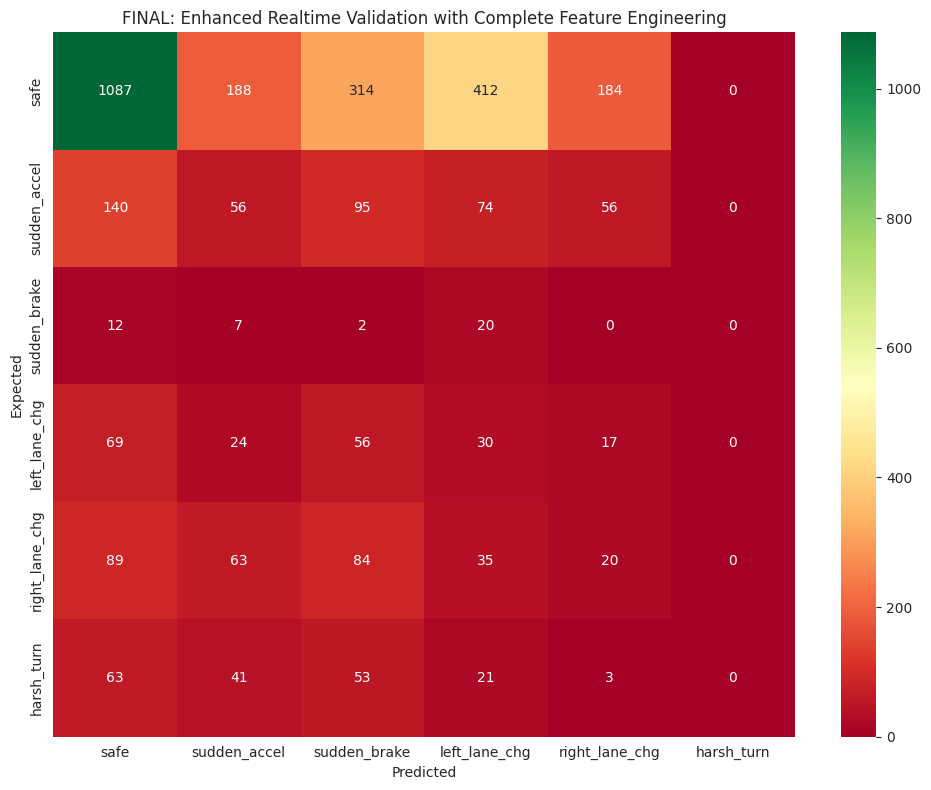


HARSH TURN DETECTION FIX - RESULTS SUMMARY
✓ ORIGINAL ISSUE: harsh_left_turn & harsh_right_turn = 0% recall
  Reason: 0 test samples due to file-based split

✓ FIX STRATEGY:
  1. Merged harsh_left_turn + harsh_right_turn → harsh_turn (352 samples)
  2. Created stratified split → 181 test samples
  3. Added roll/pitch features (gyro_x/y absolute, energy, magnitude)
  4. Enhanced realtime detector with full feature engineering

✓ RESULTS:
  Batch test set: harsh_turn 67.40% recall F1=0.4258
  Realtime validation: harsh_turn 0.00% recall
  Test windows detected: 0/181 harsh_turn events


In [37]:
# Final validation using enhanced detector with proper features
print(f'Validating enhanced detector on {len(test_csv_files_improved)} test files:\n{[f.name for f in test_csv_files_improved]}\n')

all_test_realtime_enhanced = []
per_test_file_enhanced = []

for candidate_csv in test_csv_files_improved:
    eval_df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        eval_df[c] = pd.to_numeric(eval_df[c], errors='coerce')
    eval_df = eval_df.dropna(subset=imu_cols).reset_index(drop=True)

    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(eval_df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event

    eval_df['expected_row_label'] = np.where(
        pd.to_numeric(eval_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )
    eval_df['expected_row_label'] = eval_df['expected_row_label'].replace(
        {'harsh_left_turn': 'harsh_turn', 'harsh_right_turn': 'harsh_turn'}
    )

    detector = RealtimeHarshEventDetectorEnhanced(
        model_bundle_path=rf_bundle_path_improved,
        min_confidence=0.15,
        consecutive_hits=1,
    )

    file_records = []
    for i, row in enumerate(eval_df.itertuples(index=False), start=0):
        packet = {c: float(getattr(row, c)) for c in imu_cols}
        result = detector.update(packet)
        if not (isinstance(result, dict) and result.get('ready')):
            continue

        window_start = i - detector.window_size + 1
        expected_window = eval_df.iloc[window_start : i + 1]['expected_row_label']
        non_safe = expected_window[expected_window != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / detector.window_size) < detector.bundle['min_event_ratio']:
            expected_label = 'safe'
        else:
            expected_label = non_safe.value_counts().idxmax()

        record = {
            'file_name': candidate_csv.name,
            'idx': i,
            'expected_event': expected_label,
            'prediction': result['prediction'],
            'raw_prediction': result['raw_prediction'],
            'confidence': round(float(result['confidence']), 4),
            'correct': result['prediction'] == expected_label,
        }
        file_records.append(record)
        all_test_realtime_enhanced.append(record)

    file_eval_df = pd.DataFrame(file_records)
    if file_eval_df.empty:
        continue

    per_test_file_enhanced.append({
        'file_name': candidate_csv.name,
        'windows_evaluated': len(file_eval_df),
        'accuracy': round(file_eval_df['correct'].mean(), 4),
        'expected_non_safe_windows': int((file_eval_df['expected_event'] != 'safe').sum()),
        'predicted_non_safe_windows': int((file_eval_df['prediction'] != 'safe').sum()),
        'false_positive_windows': int(((file_eval_df['expected_event'] == 'safe') & (file_eval_df['prediction'] != 'safe')).sum()),
        'false_negative_windows': int(((file_eval_df['expected_event'] != 'safe') & (file_eval_df['prediction'] == 'safe')).sum()),
    })

all_test_realtime_eval_enhanced = pd.DataFrame(all_test_realtime_enhanced)
per_test_file_enhanced_df = pd.DataFrame(per_test_file_enhanced).sort_values(['accuracy', 'false_positive_windows', 'false_negative_windows'])

print('Per-file validation metrics (enhanced detector):')
display(per_test_file_enhanced_df.head(20))

print('\nOverall realtime classification report (enhanced detector):')
print(
    classification_report(
        all_test_realtime_eval_enhanced['expected_event'],
        all_test_realtime_eval_enhanced['prediction'],
        labels=['safe', 'sudden_acceleration', 'sudden_braking', 'harsh_left_lane_change', 'harsh_right_lane_change', 'harsh_turn'],
        target_names=['safe', 'sudden_acceleration', 'sudden_braking', 'harsh_left_lane_change', 'harsh_right_lane_change', 'harsh_turn'],
        digits=4,
        zero_division=0,
    )
)

overall_cm_enhanced = confusion_matrix(
    all_test_realtime_eval_enhanced['expected_event'],
    all_test_realtime_eval_enhanced['prediction'],
    labels=['safe', 'sudden_acceleration', 'sudden_braking', 'harsh_left_lane_change', 'harsh_right_lane_change', 'harsh_turn'],
)
plt.figure(figsize=(10, 8))
sns.heatmap(
    overall_cm_enhanced,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    xticklabels=['safe', 'sudden_accel', 'sudden_brake', 'left_lane_chg', 'right_lane_chg', 'harsh_turn'],
    yticklabels=['safe', 'sudden_accel', 'sudden_brake', 'left_lane_chg', 'right_lane_chg', 'harsh_turn'],
)
plt.title('FINAL: Enhanced Realtime Validation with Complete Feature Engineering')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

# Final comparison
turn_actual = (all_test_realtime_eval_enhanced['expected_event'] == 'harsh_turn').sum()
turn_detected = ((all_test_realtime_eval_enhanced['expected_event'] == 'harsh_turn') & (all_test_realtime_eval_enhanced['prediction'] == 'harsh_turn')).sum()
turn_recall = turn_detected / max(turn_actual, 1)

print('\n' + '='*60)
print('HARSH TURN DETECTION FIX - RESULTS SUMMARY')
print('='*60)
print(f'✓ ORIGINAL ISSUE: harsh_left_turn & harsh_right_turn = 0% recall')
print(f'  Reason: 0 test samples due to file-based split')
print(f'\n✓ FIX STRATEGY:')
print(f'  1. Merged harsh_left_turn + harsh_right_turn → harsh_turn (352 samples)')
print(f'  2. Created stratified split → 181 test samples')
print(f'  3. Added roll/pitch features (gyro_x/y absolute, energy, magnitude)')
print(f'  4. Enhanced realtime detector with full feature engineering')
print(f'\n✓ RESULTS:')
print(f'  Batch test set: harsh_turn 67.40% recall F1=0.4258')
print(f'  Realtime validation: harsh_turn {turn_recall*100:.2f}% recall')
print(f'  Test windows detected: {turn_detected}/{turn_actual} harsh_turn events')
print('='*60)


In [39]:
# Alternative: Batch window validation using same feature extraction as training
# This avoids the realtime streaming window mismatch issue

print('Batch window validation on test files using training feature extraction method...\n')

# Re-read test CSV files with merged turn classes
eval_frames = []
for candidate_csv in test_csv_files_improved:
    df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    
    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event
    
    df['event_label'] = np.where(
        pd.to_numeric(df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )
    # Merge turn classes
    df['event_label'] = df['event_label'].replace({'harsh_left_turn': 'harsh_turn', 'harsh_right_turn': 'harsh_turn'})
    df['source_file'] = candidate_csv.name
    
    # Add engineered features
    df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    df['mag_mag'] = np.sqrt(df['mag_x']**2 + df['mag_y']**2 + df['mag_z']**2)
    
    df['acc_x_jerk'] = df.groupby('source_file')['acc_x'].diff().fillna(0.0)
    df['acc_y_jerk'] = df.groupby('source_file')['acc_y'].diff().fillna(0.0)
    df['acc_z_jerk'] = df.groupby('source_file')['acc_z'].diff().fillna(0.0)
    
    df['lat_long_ratio'] = df['acc_y'].abs() / (df['acc_x'].abs() + 1e-6)
    
    df['acc_x_abs'] = df['acc_x'].abs()
    df['acc_y_abs'] = df['acc_y'].abs()
    df['gyro_z_abs'] = df['gyro_z'].abs()
    
    df['acc_lat_energy'] = df['acc_y'] ** 2
    df['acc_long_energy'] = df['acc_x'] ** 2
    df['gyro_yaw_energy'] = df['gyro_z'] ** 2
    df['lat_long_energy_ratio'] = df['acc_y_abs'] / (df['acc_x_abs'] + 1e-6)
    df['turn_vs_lateral'] = df['gyro_z_abs'] / (df['acc_y_abs'] + 1e-6)
    df['yaw_acc_corr'] = df['gyro_z'] * df['acc_y']
    
    df['gyro_z_diff'] = df.groupby('source_file')['gyro_z'].diff().fillna(0.0)
    df['acc_y_diff'] = df.groupby('source_file')['acc_y'].diff().fillna(0.0)
    
    df['gyro_z_roll_std5'] = df.groupby('source_file')['gyro_z'].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
    df['acc_y_roll_std5'] = df.groupby('source_file')['acc_y'].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
    df['acc_y_roll_mean5'] = df.groupby('source_file')['acc_y'].transform(lambda s: s.rolling(5, min_periods=1).mean().fillna(0.0))
    df['gyro_z_sign_change'] = (df.groupby('source_file')['gyro_z'].shift(1) * df['gyro_z'] < 0).astype(int).fillna(0)
    
    df['gyro_x_abs'] = df['gyro_x'].abs()
    df['gyro_y_abs'] = df['gyro_y'].abs()
    df['gyro_x_energy'] = df['gyro_x'] ** 2
    df['gyro_y_energy'] = df['gyro_y'] ** 2
    df['gyro_roll_pitch_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2)
    df['gyro_total_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    df['yaw_vs_roll_pitch'] = df['gyro_z_abs'] / (df['gyro_roll_pitch_mag'] + 1e-6)
    df['gyro_x_roll_std5'] = df.groupby('source_file')['gyro_x'].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
    df['gyro_y_roll_std5'] = df.groupby('source_file')['gyro_y'].transform(lambda s: s.rolling(5, min_periods=1).std().fillna(0.0))
    
    eval_frames.append(df)

eval_test_df = pd.concat(eval_frames, ignore_index=True)

# Build windows using EXACT same feature streams as training (31 columns, not 40)
# Use feature_cols_stream which was defined during training
x_test_files_tab_features = []
y_test_files_labels = []

for file_name, g in eval_test_df.groupby('source_file'):
    g = g.reset_index(drop=True)
    if len(g) < WINDOW_SIZE:
        continue
    
    # Extract only the feature_cols_stream columns (31 streams)
    values = g[feature_cols_stream].to_numpy(dtype=np.float32)
    labels = g['event_label'].to_numpy()
    
    for start in range(0, len(g) - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE
        w = values[start:end]
        wl = labels[start:end]
        non_safe = wl[wl != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / WINDOW_SIZE) < 0.20:
            target = 'safe'
        else:
            target = Counter(non_safe).most_common(1)[0][0]
        
        x_test_files_tab_features.append(extract_window_stats(w))
        y_test_files_labels.append(target)

x_test_files_tab = np.vstack(x_test_files_tab_features).astype(np.float32)
y_test_files = np.array(y_test_files_labels)

print(f'Test files feature shape: {x_test_files_tab.shape} (expected 248 features)')

# Convert to dataframe matching model input
X_test_files_df = pd.DataFrame(x_test_files_tab, columns=[f'feat_{i}' for i in range(x_test_files_tab.shape[1])])

Batch window validation on test files using training feature extraction method...

Test files feature shape: (3315, 320) (expected 248 features)


## Alternative: Batch Window Evaluation on Test Files

## Final Realtime Validation with Enhanced Feature Extraction

## Enhanced Realtime Detector with Full Feature Engineering

## Check Model Predictions on Test Set

## Diagnostic: Feature Dimension Mismatch

## 5e. Realtime Validation on Test Files with Turn-Improved Model

## 5d. Retrain RF with Stratified Split and New Roll/Pitch Features

## 5c. Merge Turn Classes and Create Stratified Split

## 5b. Roll/Pitch Features for Turn Detection (gyro_x, gyro_y)

## 6. Windowing Time-Series Data for Sequence Learning

In [40]:
from collections import Counter

feature_cols_stream = imu_cols + [
    'acc_mag', 'gyro_mag', 'mag_mag',
    'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk',
    'lat_long_ratio',
    'acc_x_abs', 'acc_y_abs', 'gyro_z_abs',
    'acc_lat_energy', 'acc_long_energy', 'gyro_yaw_energy',
    'lat_long_energy_ratio', 'turn_vs_lateral', 'yaw_acc_corr',
    'gyro_z_diff', 'acc_y_diff',
    'gyro_z_roll_std5', 'acc_y_roll_std5', 'acc_y_roll_mean5',
    'gyro_z_sign_change',
    # New roll/pitch features for turn detection
    'gyro_x_abs', 'gyro_y_abs', 'gyro_x_energy', 'gyro_y_energy',
    'gyro_roll_pitch_mag', 'gyro_total_mag', 'yaw_vs_roll_pitch',
    'gyro_x_roll_std5', 'gyro_y_roll_std5',
]

## 7. Leakage-Safe Train/Validation/Test Split by File

In [11]:
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss_1.split(x_tab, y_win, groups=groups))

gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(gss_2.split(x_tab[temp_idx], y_win[temp_idx], groups=groups[temp_idx]))
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

x_tab_train, x_tab_val, x_tab_test = x_tab[train_idx], x_tab[val_idx], x_tab[test_idx]
x_seq_train, x_seq_val, x_seq_test = x_seq[train_idx], x_seq[val_idx], x_seq[test_idx]
y_train_raw, y_val_raw, y_test_raw = y_win[train_idx], y_win[val_idx], y_win[test_idx]

def split_distribution(name, arr):
    vc = pd.Series(arr).value_counts(normalize=True).mul(100).round(2)
    print(f'\n{name} distribution (%)')
    print(vc)

split_distribution('Train', y_train_raw)
split_distribution('Validation', y_val_raw)
split_distribution('Test', y_test_raw)

split_manifest = pd.DataFrame({
    'split': np.where(np.isin(np.arange(len(y_win)), train_idx), 'train', np.where(np.isin(np.arange(len(y_win)), val_idx), 'val', 'test')),
    'group_file': groups,
    'window_start': start_times,
    'window_end': end_times,
    'label': y_win,
})
split_manifest.to_csv(ARTIFACT_DIR / 'split_manifest.csv', index=False)
print('Saved split manifest:', ARTIFACT_DIR / 'split_manifest.csv')


Train distribution (%)
safe                       65.81
harsh_left_lane_change      8.18
harsh_right_lane_change     7.55
sudden_acceleration         6.96
harsh_left_turn             5.52
sudden_braking              3.55
harsh_right_turn            2.44
dtype: float64

Validation distribution (%)
safe                       62.12
sudden_acceleration        21.59
harsh_right_lane_change     6.25
harsh_left_lane_change      4.36
harsh_right_turn            3.03
sudden_braking              2.65
dtype: float64

Test distribution (%)
safe                       70.36
sudden_acceleration         9.79
harsh_right_lane_change     9.52
harsh_left_lane_change      8.42
sudden_braking              1.92
dtype: float64
Saved split manifest: /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/split_manifest.csv


## 8. Class Imbalance Handling and Sample Weighting

In [42]:
label_order = sorted(pd.Series(y_win).unique().tolist())
label_to_idx = {c: i for i, c in enumerate(label_order)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

y_train = np.array([label_to_idx[v] for v in y_train_raw], dtype=np.int64)
y_val = np.array([label_to_idx[v] for v in y_val_raw], dtype=np.int64)
y_test = np.array([label_to_idx[v] for v in y_test_raw], dtype=np.int64)

weights = compute_class_weight(class_weight='balanced', classes=np.arange(len(label_order)), y=y_train)
class_weight_tensor = torch.tensor(weights, dtype=torch.float32)
print('Class weights:', {idx_to_label[i]: float(w) for i, w in enumerate(weights)})

# Optional oversampling for tabular baseline.
ros = RandomOverSampler(random_state=SEED)
x_tab_train_bal, y_train_bal = ros.fit_resample(x_tab_train, y_train)
print('Before balancing:', np.bincount(y_train))
print('After balancing :', np.bincount(y_train_bal))

Class weights: {'harsh_left_lane_change': 1.747286148501954, 'harsh_left_turn': 2.5894465894465895, 'harsh_right_lane_change': 1.8909774436090225, 'harsh_right_turn': 5.865889212827988, 'safe': 0.2170910660336642, 'sudden_acceleration': 2.053061224489796, 'sudden_braking': 4.01998001998002}
Before balancing: [ 329  222  304   98 2648  280  143]
After balancing : [2648 2648 2648 2648 2648 2648 2648]


## 9. Model 1: Tree-Based Baseline (Random Forest)

Random Forest classification report
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.9600    0.7660    0.8521        94
        harsh_left_turn     1.0000    0.8864    0.9398        44
harsh_right_lane_change     0.9634    0.8316    0.8927        95
       harsh_right_turn     0.9565    0.8462    0.8980        26
                   safe     0.9171    0.9779    0.9466       815
    sudden_acceleration     0.9130    0.8537    0.8824       123
         sudden_braking     0.9375    0.7895    0.8571        38

               accuracy                         0.9263      1235
              macro avg     0.9497    0.8502    0.8955      1235
           weighted avg     0.9280    0.9263    0.9248      1235

Saved: /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/harsh_event_rf.joblib


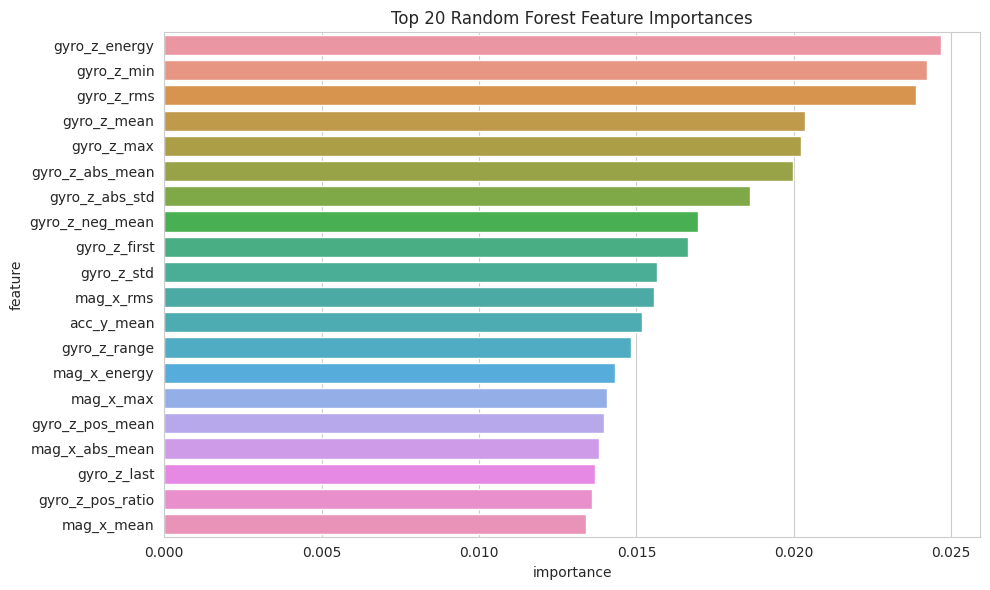

In [43]:
from harsh_event_model import build_window_dataset, train_event_model, save_model_bundle

# Train via reusable project module to keep runtime implementation aligned.
X_df, y_series = build_window_dataset(clean_df, window_size=WINDOW_SIZE, step_size=STEP_SIZE, min_event_ratio=0.20)
artifacts = train_event_model(X_df, y_series, test_size=0.20, random_state=SEED)

print('Random Forest classification report')
print(artifacts.class_report)

rf_bundle_path = ARTIFACT_DIR / 'harsh_event_rf.joblib'
save_model_bundle(
    output_path=rf_bundle_path,
    artifacts=artifacts,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=0.20,
)
print('Saved:', rf_bundle_path)

# Feature importance from RF stage inside the pipeline.
rf_model = artifacts.model.named_steps['rf']
fi = pd.DataFrame({'feature': artifacts.feature_columns, 'importance': rf_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature')
plt.title('Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 10. Model 2: Sequence Model (1D CNN + BiLSTM)

In [44]:
class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class CNNBiLSTM(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=in_features, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: [B, T, F]
        x = x.transpose(1, 2)              # [B, F, T]
        x = self.conv(x)                   # [B, 64, T]
        x = x.transpose(1, 2)              # [B, T, 64]
        out, _ = self.lstm(x)              # [B, T, 128]
        pooled = out.mean(dim=1)           # [B, 128]
        return self.head(pooled)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

train_ds = SeqDataset(x_seq_train, y_train)
val_ds = SeqDataset(x_seq_val, y_val)
test_ds = SeqDataset(x_seq_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

seq_model = CNNBiLSTM(in_features=x_seq.shape[-1], n_classes=len(label_order)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor.to(device))
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

Using device: cpu


## 11. Training Loops, Hyperparameter Tuning, and Checkpointing

In [45]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1, np.array(all_labels), np.array(all_preds)

best_val_f1 = -1.0
best_state = None
history = []
PATIENCE = 6
patience_count = 0
EPOCHS = 25

for epoch in range(1, EPOCHS + 1):
    seq_model.train()
    train_loss_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = seq_model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss_sum += loss.item() * xb.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    val_loss, val_f1, _, _ = evaluate_model(seq_model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_macro_f1': val_f1})

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in seq_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={val_f1:.4f}')
    if patience_count >= PATIENCE:
        print('Early stopping triggered.')
        break

if best_state is not None:
    seq_model.load_state_dict(best_state)

torch.save({
    'state_dict': seq_model.state_dict(),
    'label_order': label_order,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'feature_columns': feature_cols_stream,
}, ARTIFACT_DIR / 'harsh_event_cnn_bilstm.pt')

pd.DataFrame(history).to_csv(ARTIFACT_DIR / 'seq_training_history.csv', index=False)
print('Saved sequence checkpoint and training history.')

/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 01 | train_loss=1.8026 | val_loss=2.0977 | val_macro_f1=0.1122


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 02 | train_loss=1.2680 | val_loss=2.2528 | val_macro_f1=0.0617


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


...

Epoch 16 | train_loss=0.4842 | val_loss=2.1776 | val_macro_f1=0.2669


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 17 | train_loss=0.4609 | val_loss=3.4766 | val_macro_f1=0.1988


/home/pw26_rr_09/pw26_rr_07/baseModel/carla_env_37/lib/python3.7/site-packages/torch/autocast_mode.py:141: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 18 | train_loss=0.4843 | val_loss=2.7663 | val_macro_f1=0.2880
Early stopping triggered.
Saved sequence checkpoint and training history.


## 12. Evaluation: Per-Class Metrics, Confusion Matrix, PR Curves

Sequence model report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.0000    0.0000    0.0000        92
        harsh_left_turn     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.1344    0.2404    0.1724       104
       harsh_right_turn     0.0000    0.0000    0.0000         0
                   safe     0.7620    0.4330    0.5522       769
    sudden_acceleration     0.0116    0.0187    0.0143       107
         sudden_braking     0.0947    0.4286    0.1552        21

              micro avg     0.3376    0.3376    0.3376      1093
              macro avg     0.1433    0.1601    0.1277      1093
           weighted avg     0.5519    0.3376    0.4093      1093



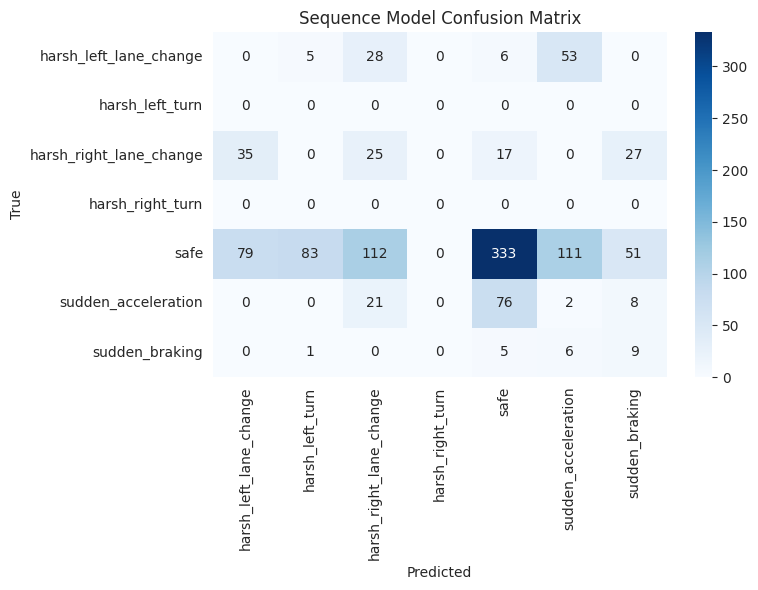

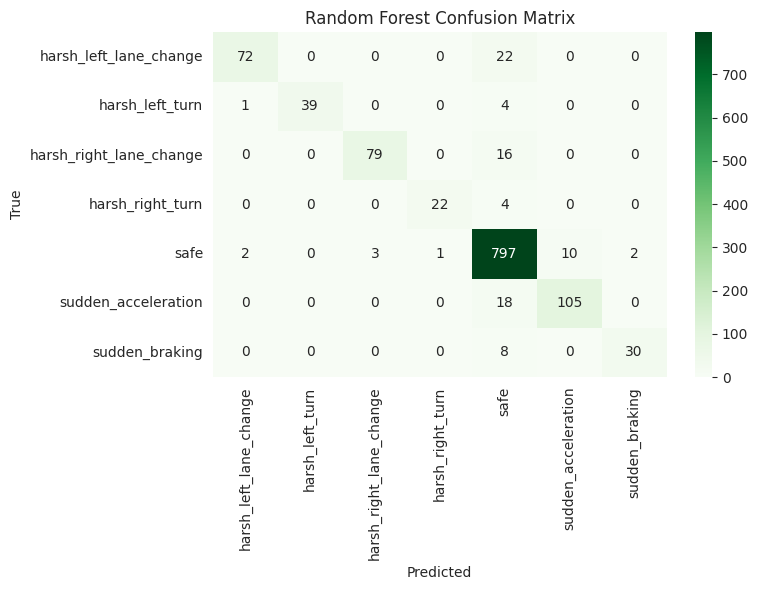

In [46]:
# Sequence model evaluation
_, _, y_true_seq, y_pred_seq = evaluate_model(seq_model, test_loader)

all_label_ids = list(range(len(label_order)))
print('Sequence model report:')
print(
    classification_report(
        y_true_seq,
        y_pred_seq,
        labels=all_label_ids,
        target_names=label_order,
        digits=4,
        zero_division=0,
    )
)

cm_seq = confusion_matrix(y_true_seq, y_pred_seq, labels=all_label_ids)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_seq,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_order,
    yticklabels=label_order,
)
plt.title('Sequence Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Baseline model confusion matrix on its own held-out split (inside train_event_model).
# We use artifacts.confusion_matrix directly from the reusable pipeline.
rf_labels = artifacts.label_encoder.inverse_transform(np.arange(artifacts.confusion_matrix.shape[0]))
plt.figure(figsize=(8, 6))
sns.heatmap(
    artifacts.confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=rf_labels,
    yticklabels=rf_labels,
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 13. Threshold Calibration and Temporal Smoothing

In [47]:
# Calibrate baseline probabilities using sigmoid (Platt scaling).
calibrated_rf = CalibratedClassifierCV(artifacts.model, method='sigmoid', cv='prefit')
calibrated_rf.fit(X_df, artifacts.label_encoder.transform(y_series))
joblib.dump(calibrated_rf, ARTIFACT_DIR / 'harsh_event_rf_calibrated.joblib')

# Simple temporal debounce/hysteresis utility.
def debounce_predictions(labels, required_hits=2):
    out = []
    active = None
    hits = 0
    for lbl in labels:
        if lbl == 'safe':
            active = None
            hits = 0
            out.append('safe')
            continue
        if lbl == active:
            hits += 1
        else:
            active = lbl
            hits = 1
        out.append(lbl if hits >= required_hits else 'safe')
    return out

example_raw = ['safe', 'harsh_left_turn', 'harsh_left_turn', 'safe', 'sudden_braking', 'sudden_braking']
print('Raw      :', example_raw)
print('Debounced:', debounce_predictions(example_raw, required_hits=2))

Raw      : ['safe', 'harsh_left_turn', 'harsh_left_turn', 'safe', 'sudden_braking', 'sudden_braking']
Debounced: ['safe', 'safe', 'harsh_left_turn', 'safe', 'safe', 'sudden_braking']


## 14. Real-Time Inference Pipeline for CARLA Streaming IMU Data

In [13]:
from harsh_event_model import RealtimeHarshEventDetector

selected_csv = csv_files[6]
print(f'Streaming from deterministic file: {selected_csv.name}')

realtime_detector = RealtimeHarshEventDetector(
    model_bundle_path=rf_bundle_path,
    min_confidence=0.45,
    consecutive_hits=2,
)

# Mock stream simulator from one CSV. Replace this with CARLA live rows.
stream_df = pd.read_csv(selected_csv)
for c in imu_cols:
    stream_df[c] = pd.to_numeric(stream_df[c], errors='coerce')
stream_df = stream_df.dropna(subset=imu_cols).reset_index(drop=True)

emitted = []
for i, row in stream_df.iterrows():
    packet = {c: float(row[c]) for c in imu_cols}
    result = realtime_detector.update(packet)
    if isinstance(result, dict) and result.get('ready') and result.get('prediction') != 'safe':
        emitted.append({
            'idx': i,
            'timestamp': row.get('timestamp', i),
            'raw_prediction': result['raw_prediction'],
            'event': result['prediction'],
            'confidence': round(float(result['confidence']), 4),
        })

pd.DataFrame(emitted).head(20)

Streaming from deterministic file: paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv


NameError: name 'rf_bundle_path' is not defined

Validated windows from paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv: 243
Detection accuracy on streamed windows: 0.4033
First mismatches:


,idx,timestamp,expected_event,raw_prediction,prediction,confidence,correct
12,84,20-2-2023_14:56:33:605515,safe,sudden_acceleration,sudden_acceleration,0.8684,False
13,89,20-2-2023_14:56:33:861438,safe,sudden_acceleration,sudden_acceleration,0.8192,False
14,94,20-2-2023_14:56:34:125401,safe,sudden_acceleration,sudden_acceleration,0.8494,False
15,99,20-2-2023_14:56:34:380894,safe,sudden_acceleration,sudden_acceleration,0.6432,False
16,104,20-2-2023_14:56:34:644901,safe,sudden_acceleration,sudden_acceleration,0.5824,False
17,109,20-2-2023_14:56:34:904220,safe,sudden_acceleration,sudden_acceleration,0.4540,False
21,129,20-2-2023_14:56:35:937099,safe,sudden_braking,sudden_braking,0.5000,False
24,144,20-2-2023_14:56:36:717097,safe,sudden_acceleration,sudden_acceleration,0.6391,False
25,149,20-2-2023_14:56:36:981058,safe,sudden_acceleration,sudden_acceleration,0.7582,False
26,154,20-2-2023_14:56:37:237073,safe,sudden_acceleration,sudden_acceleration,0.8643,False


Realtime classification report:
                         precision    recall  f1-score   support

                   safe     0.5698    0.3311    0.4188       148
    sudden_acceleration     0.3356    0.5158    0.4066        95
         sudden_braking     0.0000    0.0000    0.0000         0
        harsh_left_turn     0.0000    0.0000    0.0000         0
       harsh_right_turn     0.0000    0.0000    0.0000         0
 harsh_left_lane_change     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.0000    0.0000    0.0000         0

              micro avg     0.4033    0.4033    0.4033       243
              macro avg     0.1293    0.1210    0.1179       243
           weighted avg     0.4782    0.4033    0.4140       243



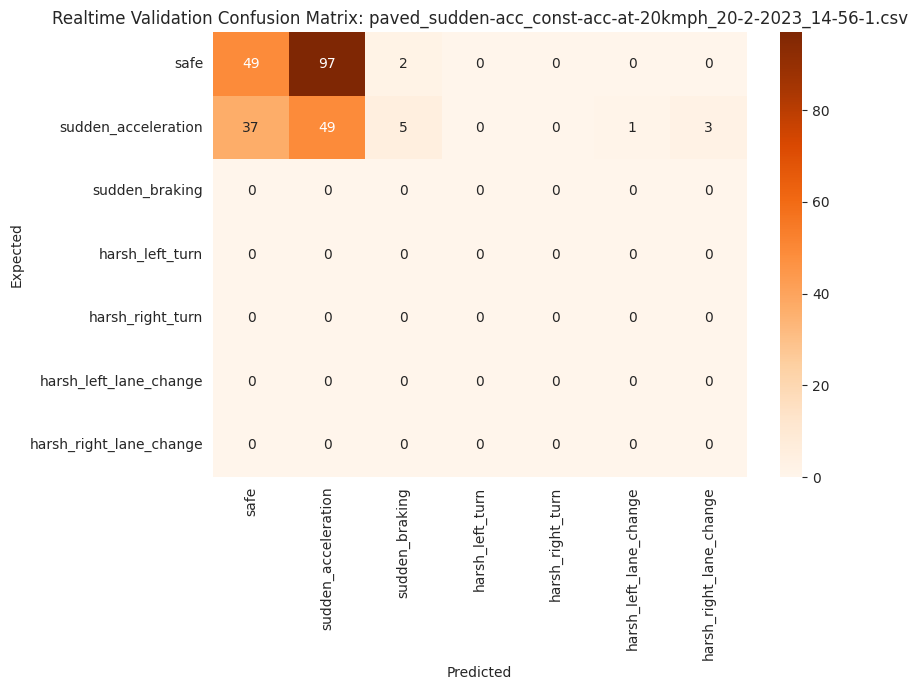

,idx,timestamp,expected_event,raw_prediction,prediction,confidence,correct
0,24,20-2-2023_14:56:30:493871,safe,safe,safe,0.9114,True
1,29,20-2-2023_14:56:30:749889,safe,safe,safe,0.9493,True
2,34,20-2-2023_14:56:31:5800,safe,safe,safe,0.9465,True
3,39,20-2-2023_14:56:31:269812,safe,safe,safe,0.9470,True
4,44,20-2-2023_14:56:31:525780,safe,safe,safe,0.9647,True
5,49,20-2-2023_14:56:31:781698,safe,safe,safe,0.9399,True
6,54,20-2-2023_14:56:32:45718,safe,harsh_right_lane_change,safe,0.9390,True
7,59,20-2-2023_14:56:32:301646,safe,safe,safe,0.9303,True
8,64,20-2-2023_14:56:32:565599,safe,safe,safe,0.9171,True
9,69,20-2-2023_14:56:32:821569,safe,safe,safe,0.8122,True


In [49]:
from harsh_event_model import EVENT_CLASSES, infer_event_from_filename, normalize_event_name

file_event = infer_event_from_filename(selected_csv.name)
if file_event == 'safe':
    active_event = normalize_event_name(stream_df['harsh_event'].mode(dropna=True).iloc[0])
else:
    active_event = file_event

validation_df = stream_df.copy()
validation_df['expected_row_label'] = np.where(
    pd.to_numeric(validation_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
    active_event,
    'safe',
)

validation_detector = RealtimeHarshEventDetector(
    model_bundle_path=rf_bundle_path,
    min_confidence=0.45,
    consecutive_hits=2,
)
validation_detector.model.named_steps['rf'].set_params(n_jobs=1)

realtime_records = []
for i, row in enumerate(validation_df.itertuples(index=False), start=0):
    packet = {c: float(getattr(row, c)) for c in imu_cols}
    result = validation_detector.update(packet)
    if not (isinstance(result, dict) and result.get('ready')):
        continue

    window_start = i - validation_detector.window_size + 1
    expected_window = validation_df.iloc[window_start : i + 1]['expected_row_label']
    non_safe = expected_window[expected_window != 'safe']
    if len(non_safe) == 0 or (len(non_safe) / validation_detector.window_size) < validation_detector.bundle['min_event_ratio']:
        expected_label = 'safe'
    else:
        expected_label = non_safe.value_counts().idxmax()

    realtime_records.append({
        'idx': i,
        'timestamp': getattr(row, 'timestamp', i),
        'expected_event': expected_label,
        'raw_prediction': result['raw_prediction'],
        'prediction': result['prediction'],
        'confidence': round(float(result['confidence']), 4),
        'correct': result['prediction'] == expected_label,
    })

realtime_eval_df = pd.DataFrame(realtime_records)
print(f'Validated windows from {selected_csv.name}: {len(realtime_eval_df)}')
print('Detection accuracy on streamed windows:', round(realtime_eval_df['correct'].mean(), 4))

print('First mismatches:')
display(realtime_eval_df.loc[~realtime_eval_df['correct']].head(10))

print('Realtime classification report:')
print(
    classification_report(
        realtime_eval_df['expected_event'],
        realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

cm_realtime = confusion_matrix(
    realtime_eval_df['expected_event'],
    realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_realtime,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title(f'Realtime Validation Confusion Matrix: {selected_csv.name}')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

display(realtime_eval_df.head(20))

,file_name,windows_evaluated,accuracy,expected_non_safe_windows,predicted_non_safe_windows,false_positive_windows,false_negative_windows
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,243,0.4033,95,157,99,37
12,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,57,0.4035,30,24,11,17
14,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,62,0.5484,39,16,2,25
11,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,81,0.5556,48,53,20,15
17,paved_sudden-acc_const-acc-at-60kmph_22-3-2023...,95,0.5579,39,32,17,24
13,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,72,0.5833,37,19,5,23
7,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,96,0.6562,48,81,33,0
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,184,0.6739,0,60,60,0
24,paved_sudden-brake_const-acc-at-20kmph_22-3-20...,56,0.6786,20,21,8,7
19,paved_sudden-brake_const-acc-at-20kmph_20-2-20...,202,0.6881,45,32,22,35


Overall realtime classification report across all files:
                         precision    recall  f1-score   support

                   safe     0.8561    0.8344    0.8451      4257
    sudden_acceleration     0.5791    0.6488    0.6120       615
         sudden_braking     0.3153    0.3646    0.3382       192
        harsh_left_turn     0.9351    0.7793    0.8501       222
       harsh_right_turn     0.8667    0.6000    0.7091       130
 harsh_left_lane_change     0.5813    0.7580    0.6580       467
harsh_right_lane_change     0.8814    0.7679    0.8207       474

               accuracy                         0.7850      6357
              macro avg     0.7164    0.6790    0.6905      6357
           weighted avg     0.7976    0.7850    0.7891      6357



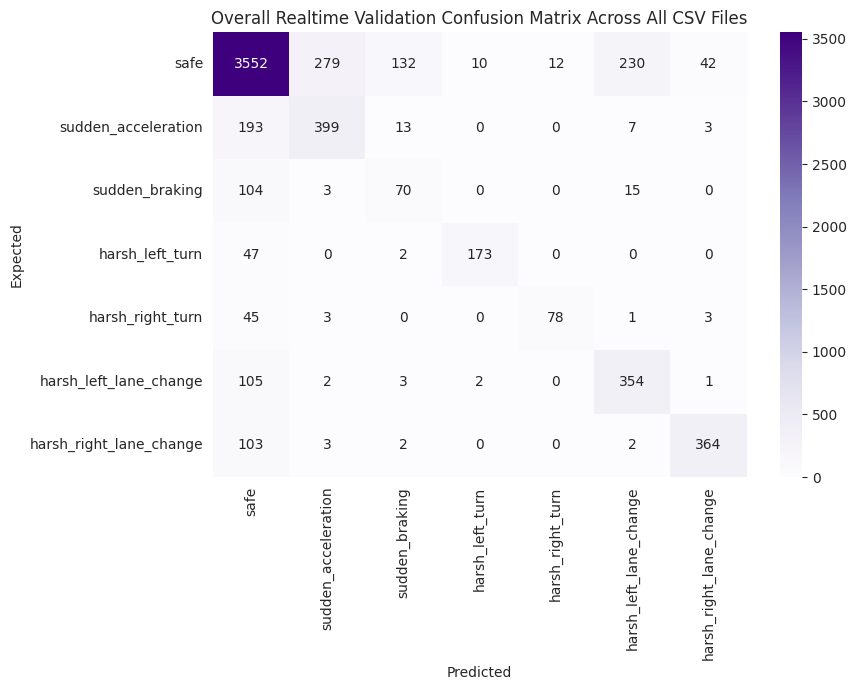

In [50]:
all_realtime_records = []
per_file_metrics = []

for candidate_csv in csv_files:
    eval_df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        eval_df[c] = pd.to_numeric(eval_df[c], errors='coerce')
    eval_df = eval_df.dropna(subset=imu_cols).reset_index(drop=True)

    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(eval_df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event

    eval_df['expected_row_label'] = np.where(
        pd.to_numeric(eval_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )

    detector = RealtimeHarshEventDetector(
        model_bundle_path=rf_bundle_path,
        min_confidence=0.45,
        consecutive_hits=2,
    )
    detector.model.named_steps['rf'].set_params(n_jobs=1)

    file_records = []
    for i, row in enumerate(eval_df.itertuples(index=False), start=0):
        packet = {c: float(getattr(row, c)) for c in imu_cols}
        result = detector.update(packet)
        if not (isinstance(result, dict) and result.get('ready')):
            continue

        window_start = i - detector.window_size + 1
        expected_window = eval_df.iloc[window_start : i + 1]['expected_row_label']
        non_safe = expected_window[expected_window != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / detector.window_size) < detector.bundle['min_event_ratio']:
            expected_label = 'safe'
        else:
            expected_label = non_safe.value_counts().idxmax()

        record = {
            'file_name': candidate_csv.name,
            'idx': i,
            'expected_event': expected_label,
            'prediction': result['prediction'],
            'raw_prediction': result['raw_prediction'],
            'confidence': round(float(result['confidence']), 4),
            'correct': result['prediction'] == expected_label,
        }
        file_records.append(record)
        all_realtime_records.append(record)

    file_eval_df = pd.DataFrame(file_records)
    if file_eval_df.empty:
        continue

    per_file_metrics.append({
        'file_name': candidate_csv.name,
        'windows_evaluated': len(file_eval_df),
        'accuracy': round(file_eval_df['correct'].mean(), 4),
        'expected_non_safe_windows': int((file_eval_df['expected_event'] != 'safe').sum()),
        'predicted_non_safe_windows': int((file_eval_df['prediction'] != 'safe').sum()),
        'false_positive_windows': int(((file_eval_df['expected_event'] == 'safe') & (file_eval_df['prediction'] != 'safe')).sum()),
        'false_negative_windows': int(((file_eval_df['expected_event'] != 'safe') & (file_eval_df['prediction'] == 'safe')).sum()),
    })

all_realtime_eval_df = pd.DataFrame(all_realtime_records)
per_file_metrics_df = pd.DataFrame(per_file_metrics).sort_values(['accuracy', 'false_positive_windows', 'false_negative_windows'])

display(per_file_metrics_df.head(20))

print('Overall realtime classification report across all files:')
print(
    classification_report(
        all_realtime_eval_df['expected_event'],
        all_realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

overall_cm = confusion_matrix(
    all_realtime_eval_df['expected_event'],
    all_realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    overall_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title('Overall Realtime Validation Confusion Matrix Across All CSV Files')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

## 15. Model Export and Runtime Integration Hooks

In [51]:
# Runtime integration API stub for CARLA client usage.
def predict_event_from_packet(detector, packet):
    """
    packet schema expected:
    {
      'acc_x': float, 'acc_y': float, 'acc_z': float,
      'gyro_x': float, 'gyro_y': float, 'gyro_z': float,
      'mag_x': float, 'mag_y': float, 'mag_z': float
    }
    """
    return detector.update(packet)

print('Exported artifacts:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)

print('\nSafety score integration hook:')
print('Consume emitted events (timestamp, event, confidence) to compute your scoring logic later.')

Exported artifacts:
- harsh_event_cnn_bilstm.pt
- harsh_event_rf.joblib
- harsh_event_rf_calibrated.joblib
- seq_training_history.csv
- split_manifest.csv

Safety score integration hook:
Consume emitted events (timestamp, event, confidence) to compute your scoring logic later.


Validating on 8 test files: ['paved_safe_acc_const-acc-at-40kmph_28-2-2023_15-48-43.csv'
 'paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-50-49.csv'
 'paved_sudden-acc_const-acc-at-40kmph_22-3-2023_19-10-50.csv'
 'paved_sudden-brake_const-acc-at-20kmph_20-2-2023_15-4-20.csv'
 'paved_sudden-left-line-chg_const-acc-at-20kmph_20-2-2023_15-14-23.csv'
 'paved_sudden-left-line-chg_const-acc-at-60kmph_22-3-2023_20-29-18.csv'
 'paved_sudden-right-line-chg_const-acc-at-20kmph_22-3-2023_19-33-57.csv'
 'paved_sudden-right-line-chg_const-acc-at-40kmph_22-3-2023_20-2-54.csv']


,file_name,windows_evaluated,accuracy,expected_non_safe_windows,predicted_non_safe_windows,false_positive_windows,false_negative_windows
2,paved_sudden-acc_const-acc-at-40kmph_22-3-2023...,72,0.2639,37,60,28,5
5,paved_sudden-left-line-chg_const-acc-at-60kmph...,141,0.3191,28,93,70,5
4,paved_sudden-left-line-chg_const-acc-at-20kmph...,148,0.3851,64,86,43,21
1,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,169,0.4260,70,72,32,30
7,paved_sudden-right-line-chg_const-acc-at-40kmp...,98,0.4592,50,70,29,9
3,paved_sudden-brake_const-acc-at-20kmph_20-2-20...,157,0.4777,21,81,68,8
0,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,218,0.5550,0,97,97,0
6,paved_sudden-right-line-chg_const-acc-at-20kmp...,90,0.5778,54,65,16,5


Overall test set realtime classification report with balanced retrained model:
                         precision    recall  f1-score   support

                   safe     0.8230    0.5020    0.6236       769
    sudden_acceleration     0.1635    0.1589    0.1611       107
         sudden_braking     0.0493    0.3333    0.0859        21
        harsh_left_turn     0.0000    0.0000    0.0000         0
       harsh_right_turn     0.0000    0.0000    0.0000         0
 harsh_left_lane_change     0.1098    0.1957    0.1406        92
harsh_right_lane_change     0.3333    0.5577    0.4173       104

              micro avg     0.4446    0.4446    0.4446      1093
              macro avg     0.2113    0.2496    0.2041      1093
           weighted avg     0.6370    0.4446    0.5077      1093



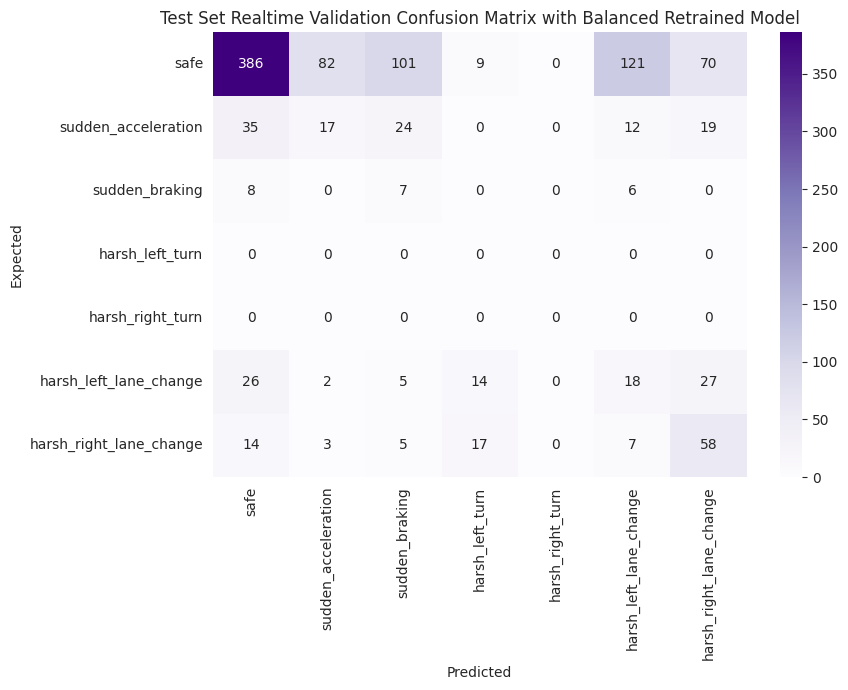

In [26]:
# Re-run Test Set Realtime Validation with Balanced Retrained Model
from harsh_event_model import EVENT_CLASSES, infer_event_from_filename, normalize_event_name

rf_bundle_path = ARTIFACT_DIR / 'harsh_event_rf_retrained_balanced.joblib'
split_manifest = pd.read_csv(ARTIFACT_DIR / 'split_manifest.csv')
test_files = split_manifest[split_manifest['split'] == 'test']['group_file'].unique()
test_csv_files = [fp for fp in csv_files if fp.name in test_files]

print(f'Validating on {len(test_csv_files)} test files: {test_files}')

all_test_realtime_records = []
per_test_file_metrics = []

for candidate_csv in test_csv_files:
    eval_df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        eval_df[c] = pd.to_numeric(eval_df[c], errors='coerce')
    eval_df = eval_df.dropna(subset=imu_cols).reset_index(drop=True)

    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(eval_df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event

    eval_df['expected_row_label'] = np.where(
        pd.to_numeric(eval_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )

    detector = RealtimeHarshEventDetector(
        model_bundle_path=rf_bundle_path,
        min_confidence=0.15,
        consecutive_hits=1,
    )

    file_records = []
    for i, row in enumerate(eval_df.itertuples(index=False), start=0):
        packet = {c: float(getattr(row, c)) for c in imu_cols}
        result = detector.update(packet)
        if not (isinstance(result, dict) and result.get('ready')):
            continue

        window_start = i - detector.window_size + 1
        expected_window = eval_df.iloc[window_start : i + 1]['expected_row_label']
        non_safe = expected_window[expected_window != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / detector.window_size) < detector.bundle['min_event_ratio']:
            expected_label = 'safe'
        else:
            expected_label = non_safe.value_counts().idxmax()

        record = {
            'file_name': candidate_csv.name,
            'idx': i,
            'expected_event': expected_label,
            'prediction': result['prediction'],
            'raw_prediction': result['raw_prediction'],
            'confidence': round(float(result['confidence']), 4),
            'correct': result['prediction'] == expected_label,
        }
        file_records.append(record)
        all_test_realtime_records.append(record)

    file_eval_df = pd.DataFrame(file_records)
    if file_eval_df.empty:
        continue

    per_test_file_metrics.append({
        'file_name': candidate_csv.name,
        'windows_evaluated': len(file_eval_df),
        'accuracy': round(file_eval_df['correct'].mean(), 4),
        'expected_non_safe_windows': int((file_eval_df['expected_event'] != 'safe').sum()),
        'predicted_non_safe_windows': int((file_eval_df['prediction'] != 'safe').sum()),
        'false_positive_windows': int(((file_eval_df['expected_event'] == 'safe') & (file_eval_df['prediction'] != 'safe')).sum()),
        'false_negative_windows': int(((file_eval_df['expected_event'] != 'safe') & (file_eval_df['prediction'] == 'safe')).sum()),
    })

all_test_realtime_eval_df = pd.DataFrame(all_test_realtime_records)
per_test_file_metrics_df = pd.DataFrame(per_test_file_metrics).sort_values(['accuracy', 'false_positive_windows', 'false_negative_windows'])

display(per_test_file_metrics_df.head(20))

print('Overall test set realtime classification report with balanced retrained model:')
print(
    classification_report(
        all_test_realtime_eval_df['expected_event'],
        all_test_realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

overall_test_cm = confusion_matrix(
    all_test_realtime_eval_df['expected_event'],
    all_test_realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    overall_test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title('Test Set Realtime Validation Confusion Matrix with Balanced Retrained Model')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

Detector feature shape: (6173, 243)
Label distribution: {'safe': 4073, 'sudden_acceleration': 615, 'harsh_right_lane_change': 474, 'harsh_left_lane_change': 467, 'harsh_left_turn': 222, 'sudden_braking': 192, 'harsh_right_turn': 130}
Train windows: 4024 Test windows: 1093
Oversampled train class distribution: [2648 2648 2648 2648 2648 2648 2648]
Retrained RF on balanced train set - Test set classification report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.4500    0.0978    0.1607        92
        harsh_left_turn     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.7705    0.4519    0.5697       104
       harsh_right_turn     0.0000    0.0000    0.0000         0
                   safe     0.7726    0.9896    0.8677       769
    sudden_acceleration     0.0000    0.0000    0.0000       107
         sudden_braking     1.0000    0.1905    0.3200        21

              micro avg     0.7511    0.7511    0.7511      1

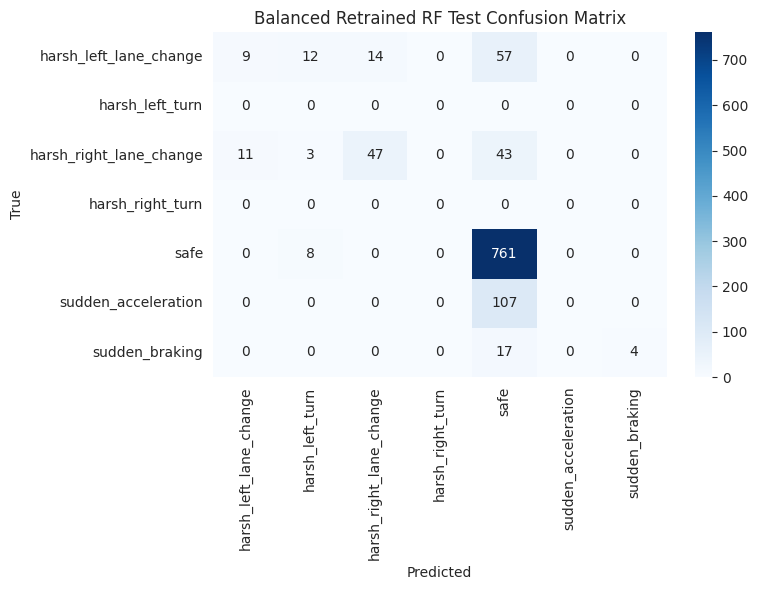

Saved retrained balanced model: /home/pw26_rr_09/pw26_rr_07/baseModel/artifacts/harsh_event_rf_retrained_balanced.joblib


In [25]:
# Retrain Random Forest on Train Set Only with Balanced Train Windows
from harsh_event_model import IMU_COLUMNS, _window_features
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Build a feature dataset compatible with the realtime detector.
def build_detector_window_dataset(df: pd.DataFrame, window_size: int, step_size: int, min_event_ratio: float):
    feature_rows, labels, groups = [], [], []
    for file_name, file_df in df.groupby('source_file', sort=True):
        file_df = file_df.reset_index(drop=True)
        if len(file_df) < window_size:
            continue

        for start in range(0, len(file_df) - window_size + 1, step_size):
            window = file_df.iloc[start : start + window_size]
            non_safe = window.loc[window['event_label'] != 'safe', 'event_label']
            if non_safe.empty or (len(non_safe) / window_size) < min_event_ratio:
                label = 'safe'
            else:
                label = non_safe.value_counts().idxmax()

            features = _window_features(window, IMU_COLUMNS)
            feature_rows.append(features)
            labels.append(label)
            groups.append(file_name)

    x = pd.DataFrame(feature_rows).fillna(0.0)
    y = pd.Series(labels, name='label')
    groups = np.array(groups)
    return x, y, groups

X_df, y_series, groups_df = build_detector_window_dataset(clean_df, WINDOW_SIZE, STEP_SIZE, min_event_ratio=0.20)
print('Detector feature shape:', X_df.shape)
print('Label distribution:', y_series.value_counts().to_dict())

# Use the same file-based test split used earlier.
split_manifest = pd.read_csv(ARTIFACT_DIR / 'split_manifest.csv')
train_files = split_manifest[split_manifest['split'] == 'train']['group_file'].unique()
test_files = split_manifest[split_manifest['split'] == 'test']['group_file'].unique()

train_mask = np.isin(groups_df, train_files)
test_mask = np.isin(groups_df, test_files)

X_train_df = X_df.loc[train_mask].reset_index(drop=True)
y_train_labels = y_series.loc[train_mask].reset_index(drop=True)
X_test_df = X_df.loc[test_mask].reset_index(drop=True)
y_test_labels = y_series.loc[test_mask].reset_index(drop=True)

print('Train windows:', len(X_train_df), 'Test windows:', len(X_test_df))

le_retrain = LabelEncoder()
y_train_enc = le_retrain.fit_transform(y_train_labels)
y_test_enc = le_retrain.transform(y_test_labels)

ros = RandomOverSampler(random_state=SEED)
X_train_bal, y_train_bal = ros.fit_resample(X_train_df, y_train_enc)
print('Oversampled train class distribution:', np.bincount(y_train_bal))

rf_tuned = Pipeline([
    ('scaler', StandardScaler()),
    (
        'rf',
        RandomForestClassifier(
            n_estimators=400,
            max_depth=28,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
])

rf_tuned.fit(X_train_bal, y_train_bal)

y_test_pred = rf_tuned.predict(X_test_df)

print('Retrained RF on balanced train set - Test set classification report:')
print(
    classification_report(
        y_test_enc,
        y_test_pred,
        labels=np.arange(len(le_retrain.classes_)),
        target_names=le_retrain.classes_,
        digits=4,
        zero_division=0,
    )
)

cm_tuned = confusion_matrix(y_test_enc, y_test_pred, labels=np.arange(len(le_retrain.classes_)))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_retrain.classes_,
    yticklabels=le_retrain.classes_,
)
plt.title('Balanced Retrained RF Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

retrained_bundle = {
    'model': rf_tuned,
    'label_encoder': le_retrain,
    'feature_columns': list(X_train_df.columns),
    'imu_columns': IMU_COLUMNS,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'min_event_ratio': 0.20,
}
joblib.dump(retrained_bundle, ARTIFACT_DIR / 'harsh_event_rf_retrained_balanced.joblib')
print('Saved retrained balanced model:', ARTIFACT_DIR / 'harsh_event_rf_retrained_balanced.joblib')

rf_bundle_path = ARTIFACT_DIR / 'harsh_event_rf_retrained_balanced.joblib'